In [27]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict

In [36]:
# firstly we are defining State 
class BMIState(TypedDict):

    weight_Kg : float 
    height_m : float 
    bmi: float
    category: str

In [44]:
def calculate_Bmi(state: BMIState ) -> BMIState:
    weight = state['weight_Kg']
    height = state['height_m']
    bmi = weight/(height**2)


    state["bmi"] = round(bmi , 2)

    
    return state 

In [45]:
def label_Bmi(state: BMIState)-> BMIState:

    bmi = state['bmi']


    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5<=bmi< 25:
        state["category"] = "Normal"
    elif 25<=bmi< 30:
        state["category"] = "OverWeight"
    else:
        state["category"] = "Obese"


        
    return state



In [46]:
# defining the graph 
graph = StateGraph(BMIState)

# add nodes to your graph 
graph.add_node('calculate_Bmi' , calculate_Bmi)
graph.add_node('label_Bmi' , label_Bmi)

# add edges to your graph 

graph.add_edge(START , 'calculate_Bmi')
graph.add_edge('calculate_Bmi' , 'label_Bmi')
graph.add_edge('label_Bmi' , END )

# we will combine the graph 
workflow = graph.compile()

# executing the graph 

In [47]:
initial_state = {'weight_Kg': 80 , 'height_m':1.73}

final_state = workflow.invoke(initial_state)

In [ ]:
print(final_state)

{'weight_Kg': 80, 'height_m': 1.73}


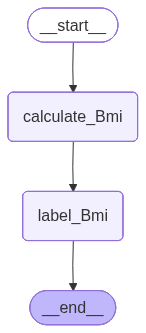

In [26]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())